In [11]:

import numpy as np
import matplotlib.pyplot as plt
import util


In [12]:
# Set path to the normalized images for further processing
path = "./normalized_images"

In [6]:
# Load the dataset
X_train, y_train = util.load_dataset(path, "train")
X_eval, y_eval = util.load_dataset(path, "val")
# load the test set later to avoid unnecessary memory usage during development
# X_test, y_test = util.load_dataset(path, "test")

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_eval.shape, y_eval.shape)

Train: (11937, 1, 224, 224) (11937,)
Val: (1470, 1, 224, 224) (1470,)


In [7]:
from sklearn.tree import DecisionTreeClassifier
import models.decisionTree as decisionTree
from sklearn.model_selection import GridSearchCV, train_test_split

param_grid = {
  'max_depth': [10, 20, 30],
  'max_features': ['sqrt', 'log2'],
  'splitter': ['best', 'random']
}

# Flatten images to 2D before grid search (GridSearchCV calls estimator directly)
X_train_flat = np.asarray(X_train).reshape(len(X_train), -1)
y_train_arr = np.asarray(y_train).ravel()

# Use only 50% of the training data for grid search
X_gs, _, y_gs, _ = train_test_split(X_train_flat, y_train_arr, train_size=0.5, random_state=42, stratify=y_train_arr)

dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(estimator=dt, 
                    param_grid=param_grid, 
                    cv=5, 
                    n_jobs=2, 
                    verbose=2
                    )
grid.fit(X_gs, y_gs)
print("Best parameters found: ", grid.best_params_)

# Retrain on full data with best params
dt_best = DecisionTreeClassifier(random_state=42, **grid.best_params_)

# Run decision tree classifier
decisionTree.run_validate(dt_best, X_train, y_train, X_eval, y_eval)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END .....max_depth=10, max_features=sqrt, splitter=best; total time=   3.9s
[CV] END .....max_depth=10, max_features=sqrt, splitter=best; total time=   4.0s
[CV] END .....max_depth=10, max_features=sqrt, splitter=best; total time=   1.8s
[CV] END .....max_depth=10, max_features=sqrt, splitter=best; total time=   2.0s
[CV] END ...max_depth=10, max_features=sqrt, splitter=random; total time=   0.8s
[CV] END ...max_depth=10, max_features=sqrt, splitter=random; total time=   0.4s
[CV] END .....max_depth=10, max_features=sqrt, splitter=best; total time=   1.6s
[CV] END ...max_depth=10, max_features=sqrt, splitter=random; total time=   0.5s
[CV] END ...max_depth=10, max_features=sqrt, splitter=random; total time=   0.4s
[CV] END ...max_depth=10, max_features=sqrt, splitter=random; total time=   0.3s
[CV] END .....max_depth=10, max_features=log2, splitter=best; total time=   0.3s
[CV] END .....max_depth=10, max_features=log2, s

In [8]:
# Test on the test set
X_test, y_test = util.load_dataset(path, "test")

decisionTree.test(dt_best, X_test, y_test)

Testing Decision Tree classifier...
Decision Tree accuracy: 0.8571  (85.71 %)
Decision Tree Classifier:
              precision    recall  f1-score   support

      NORMAL       0.96      0.80      0.87       925
   PNEUMONIA       0.75      0.94      0.84       580

    accuracy                           0.86      1505
   macro avg       0.85      0.87      0.85      1505
weighted avg       0.88      0.86      0.86      1505



In [9]:
from sklearn.ensemble import BaggingClassifier
import models.randomForest as randomForest

# Use the tuned decision tree as the base estimator for bagging
# This is equivalent to Random Forest but with our GridSearch-optimised tree params
rf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42, **grid.best_params_),
    n_estimators=100,
    n_jobs=2,
    random_state=42
)

randomForest.run_validate(rf, X_train, y_train, X_eval, y_eval)

Training Random Forest classifier...
Random Forest accuracy: 0.8639  (86.39 %)
Random Forest Classifier:
              precision    recall  f1-score   support

      NORMAL       0.96      0.82      0.88       900
   PNEUMONIA       0.76      0.94      0.84       570

    accuracy                           0.86      1470
   macro avg       0.86      0.88      0.86      1470
weighted avg       0.88      0.86      0.87      1470



Testing Random Forest classifier...
Random Forest accuracy: 0.8731  (87.31 %)
Random Forest Classifier:
              precision    recall  f1-score   support

      NORMAL       0.96      0.83      0.89       925
   PNEUMONIA       0.78      0.94      0.85       580

    accuracy                           0.87      1505
   macro avg       0.87      0.89      0.87      1505
weighted avg       0.89      0.87      0.87      1505



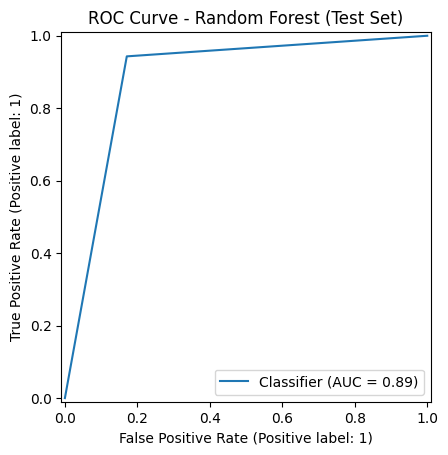

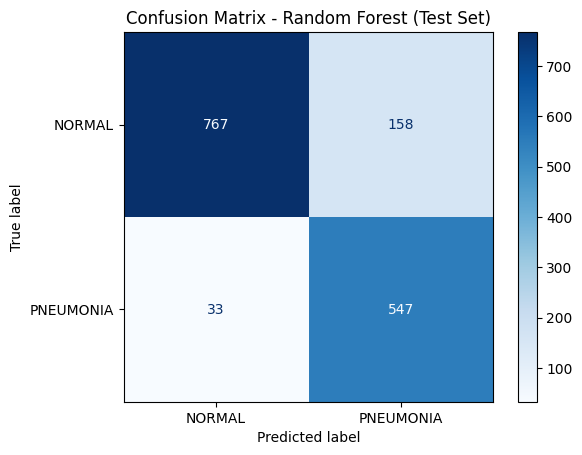

In [14]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay

# Test on the test set
X_test, y_test = util.load_dataset(path, "test")
X_test_flat = X_test.reshape(len(X_test), -1)

randomForest.test(rf, X_test, y_test)

RocCurveDisplay.from_predictions(y_test, rf.predict(X_test_flat))
plt.title("ROC Curve - Random Forest (Test Set)")
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, rf.predict(X_test_flat), display_labels=["NORMAL", "PNEUMONIA"], cmap="Blues")
plt.title("Confusion Matrix - Random Forest (Test Set)")
plt.show()

In [15]:
X_test_flat = np.asarray(X_test).reshape(len(X_test), -1)
y_test_arr = np.asarray(y_test).ravel()

np.save("preds/dt_test_preds.npy", dt_best.predict_proba(X_test_flat)[:, 1])
np.save("preds/dt_test_labels.npy", y_test_arr)
np.save("preds/rf_test_preds.npy", rf.predict_proba(X_test_flat)[:, 1])
np.save("preds/rf_test_labels.npy", y_test_arr)